# UCI Student Performance — Risk Modeling
**TR:** Bu notebook staj / mülakat sunum için Data Science pipeline'ını adım adım gösterir.  
**EN:** This notebook walks through the full DS pipeline for a student risk scoring system.

Sections:
1. Setup & data loading
2. Feature engineering + leakage check
3. EDA (class distribution, grade distributions, absence histogram, correlation heatmap)
4. Model evaluation — holdout split
5. Cross-validation (5-fold stratified)
6. Feature importance (RF pipeline)
7. SHAP analysis (Gradient Boosting)
8. Risk score preview table


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Add project src to path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.risk_model_pipeline import (
    Paths,
    build_features,
    cross_validate_models,
    download_and_load_uci,
    eda_plots,
    evaluate_models,
    feature_importance_chart,
    risk_score_preview,
    shap_analysis,
)

paths = Paths(root=PROJECT_ROOT)
paths.ensure()
print("Project root:", PROJECT_ROOT)


Project root: /home/beraer/projects/okul_asistani/data_science


In [2]:
raw_df = download_and_load_uci(paths)
raw_df.to_csv(paths.data_processed / "uci_merged.csv", index=False)

print(f"Shape: {raw_df.shape}")
print(f"Courses: {raw_df['course'].value_counts().to_dict()}")
print(f"Missing values: {raw_df.isnull().sum().sum()}")
raw_df.head()


Shape: (1044, 34)
Courses: {'por': 649, 'mat': 395}
Missing values: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


In [3]:
X, y = build_features(raw_df)

# Leakage check: G3 must not appear in X
assert "G3" not in X.columns, "DATA LEAKAGE: G3 in X!"
assert "grade_avg_mid" in X.columns, "grade_avg_mid missing — check build_features"

print(f"X shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\nRisk label distribution:")
print(y.value_counts().rename({0: 'Not at risk', 1: 'At risk'}).to_string())
print(f"\nPositive (at-risk) rate: {y.mean():.1%}")


X shape: (1044, 16)
Features: ['absences', 'absences_log', 'grade_avg_mid', 'grade_trend', 'studytime', 'failures', 'goout', 'freetime', 'schoolsup', 'famsup', 'internet', 'higher', 'course', 'age', 'sex', 'school']

Risk label distribution:
Not at risk    635
At risk        409

Positive (at-risk) rate: 39.2%


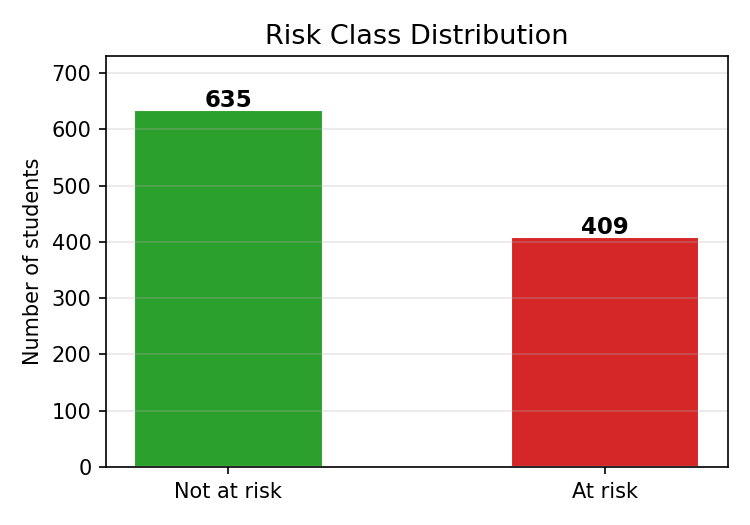

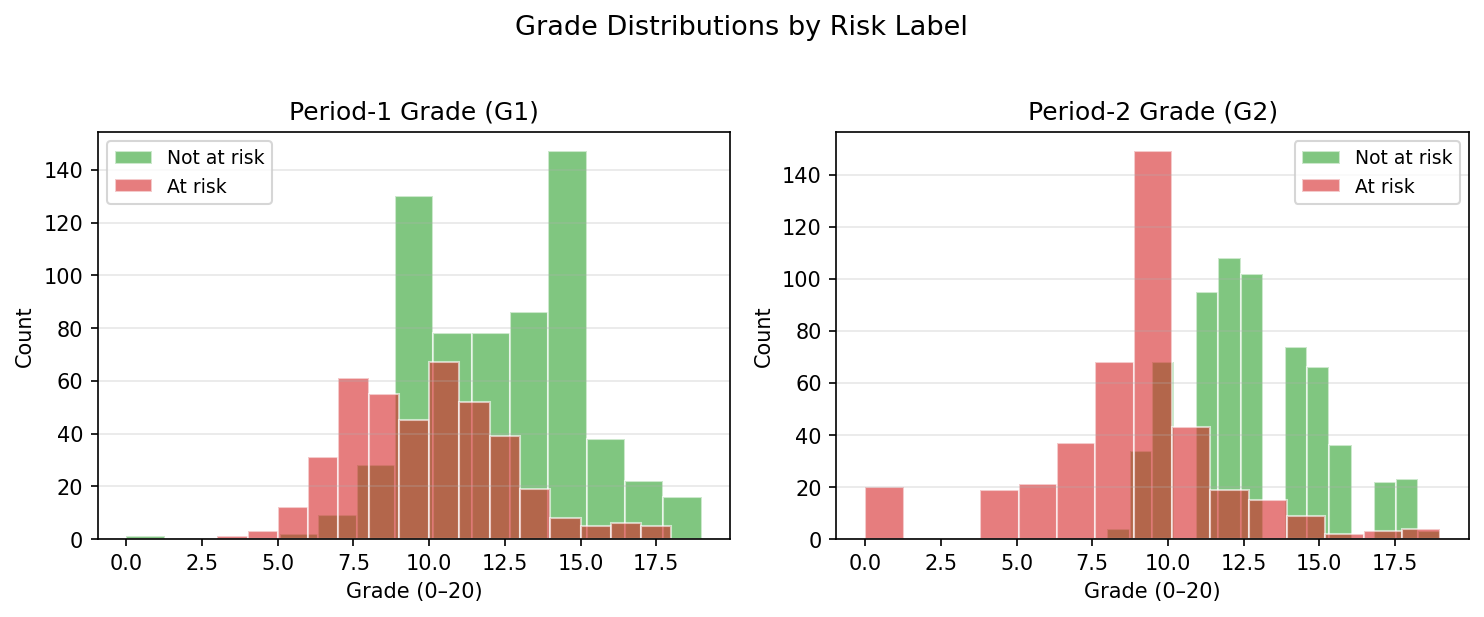

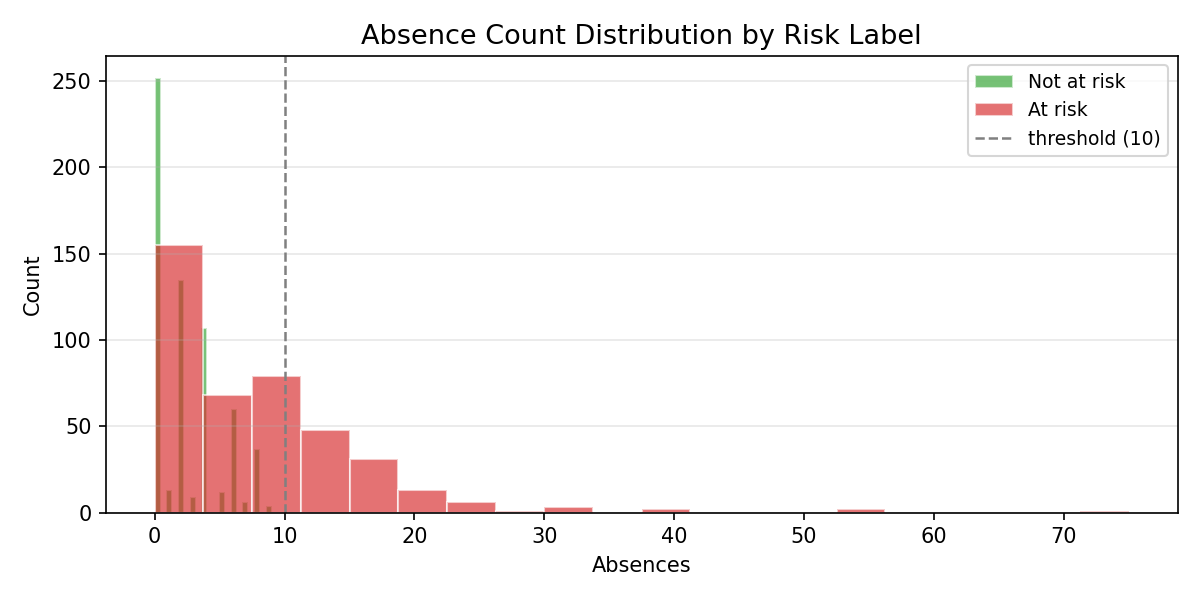

In [ ]:
# produces 3 EDA figures and saves them to reports/figures/
eda_plots(raw_df, y, paths)

# Display them inline
for fname in ["eda_class_distribution.png",
              "eda_grade_distributions.png",
              "eda_absence_distribution.png"]:
    from IPython.display import Image
    display(Image(str(paths.figures / fname)))


Holdout results (75/25 stratified split):


,model,accuracy,precision,recall,f1,roc_auc
2,gradient_boosting,0.9655,0.9515,0.9608,0.9561,0.9925
1,random_forest,0.9540,0.9412,0.9412,0.9412,0.9902
0,logistic_regression,0.9004,0.8958,0.8431,0.8687,0.9460


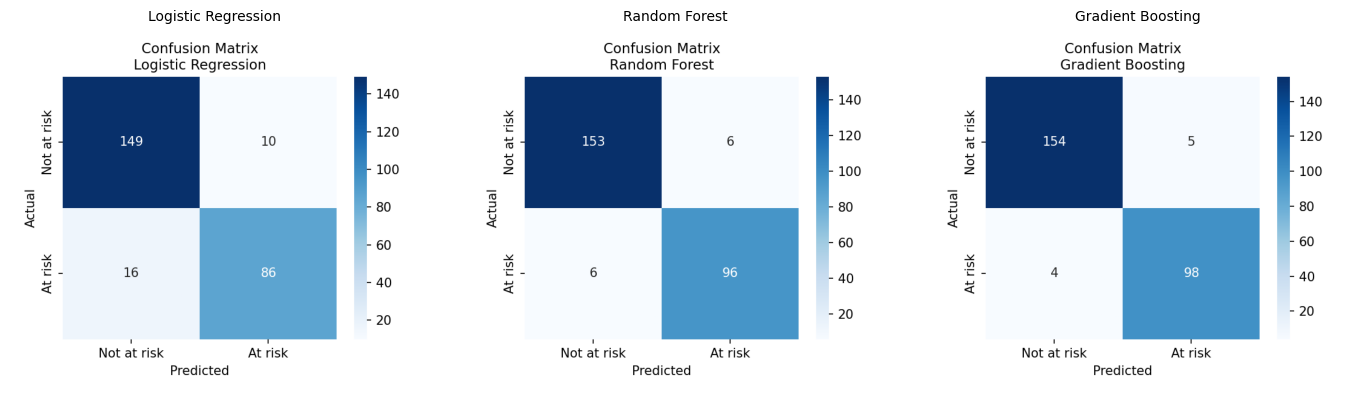

In [5]:
model_table, fitted_models = evaluate_models(X, y, paths)

print("Holdout results (75/25 stratified split):")
display(model_table)

# Confusion matrices side by side
from IPython.display import Image
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, ["logistic_regression", "random_forest", "gradient_boosting"]):
    img = plt.imread(str(paths.figures / f"confusion_matrix_{name}.png"))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(name.replace("_", " ").title(), fontsize=10)
plt.tight_layout()
plt.show()


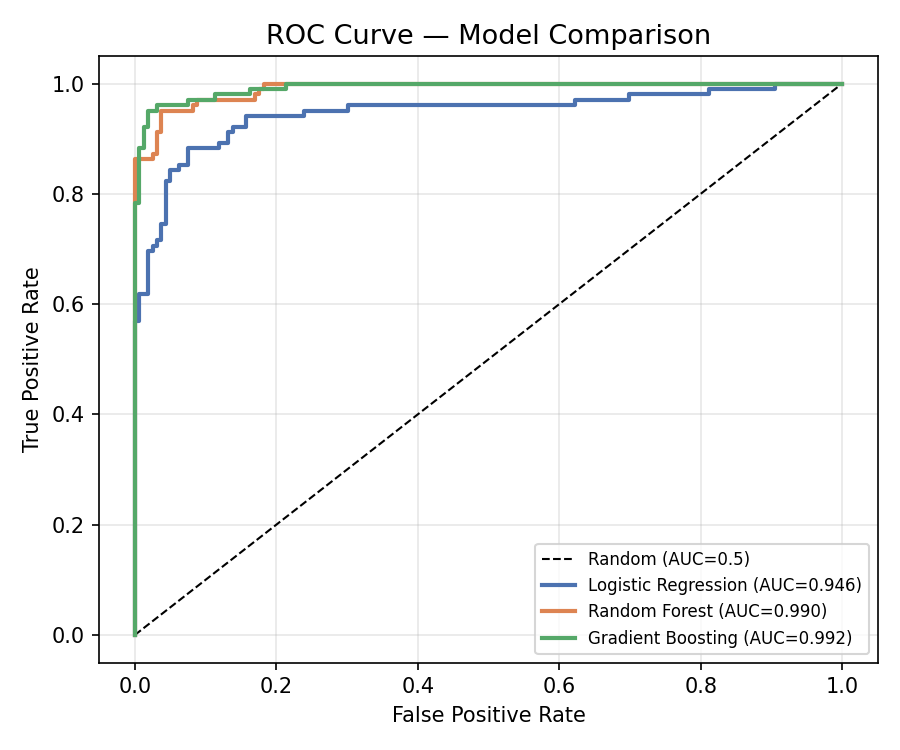

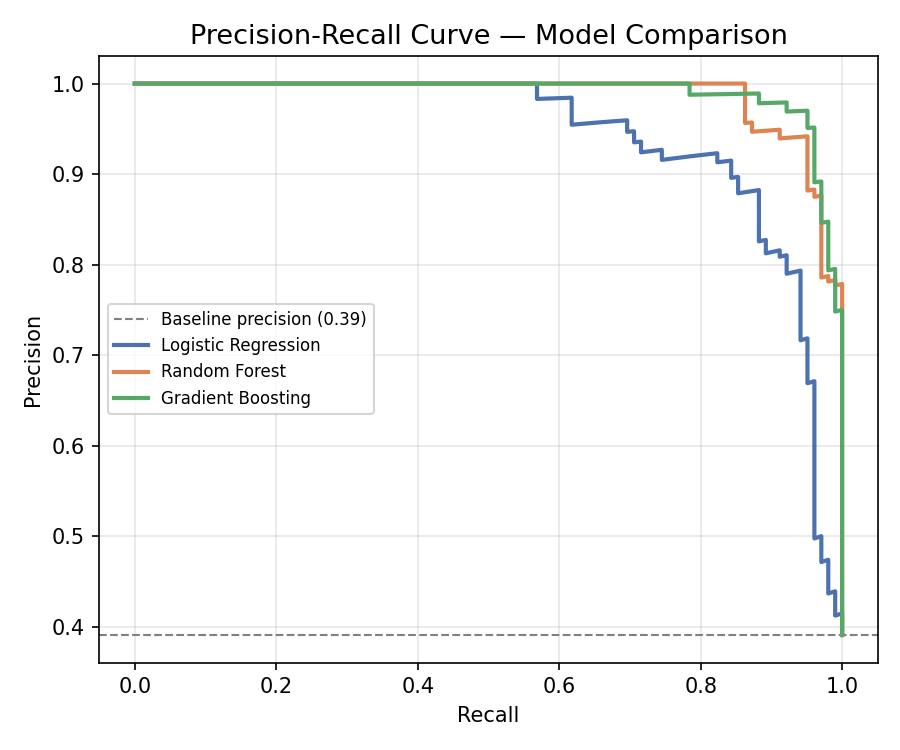

In [6]:
# ROC and Precision-Recall curves are saved by evaluate_models
from IPython.display import Image
display(Image(str(paths.figures / "roc_curve_comparison.png")))
display(Image(str(paths.figures / "precision_recall_comparison.png")))


In [7]:
cv_table = cross_validate_models(X, y, paths)

print("5-fold stratified cross-validation:")
display(cv_table)

# Compare holdout F1 vs CV F1
merged = model_table[["model", "f1"]].merge(
    cv_table[["model", "f1_mean", "f1_std"]], on="model"
).rename(columns={"f1": "holdout_f1"})
print("\nHoldout vs CV comparison:")
display(merged)


5-fold stratified cross-validation:


,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,gradient_boosting,0.9339,0.0088,0.9139,0.0126,0.9806,0.0048
1,random_forest,0.9262,0.0141,0.9015,0.0203,0.9819,0.0067
0,logistic_regression,0.8774,0.0170,0.8381,0.0267,0.9543,0.0110



Holdout vs CV comparison:


,model,holdout_f1,f1_mean,f1_std
0,gradient_boosting,0.9561,0.9139,0.0126
1,random_forest,0.9412,0.9015,0.0203
2,logistic_regression,0.8687,0.8381,0.0267


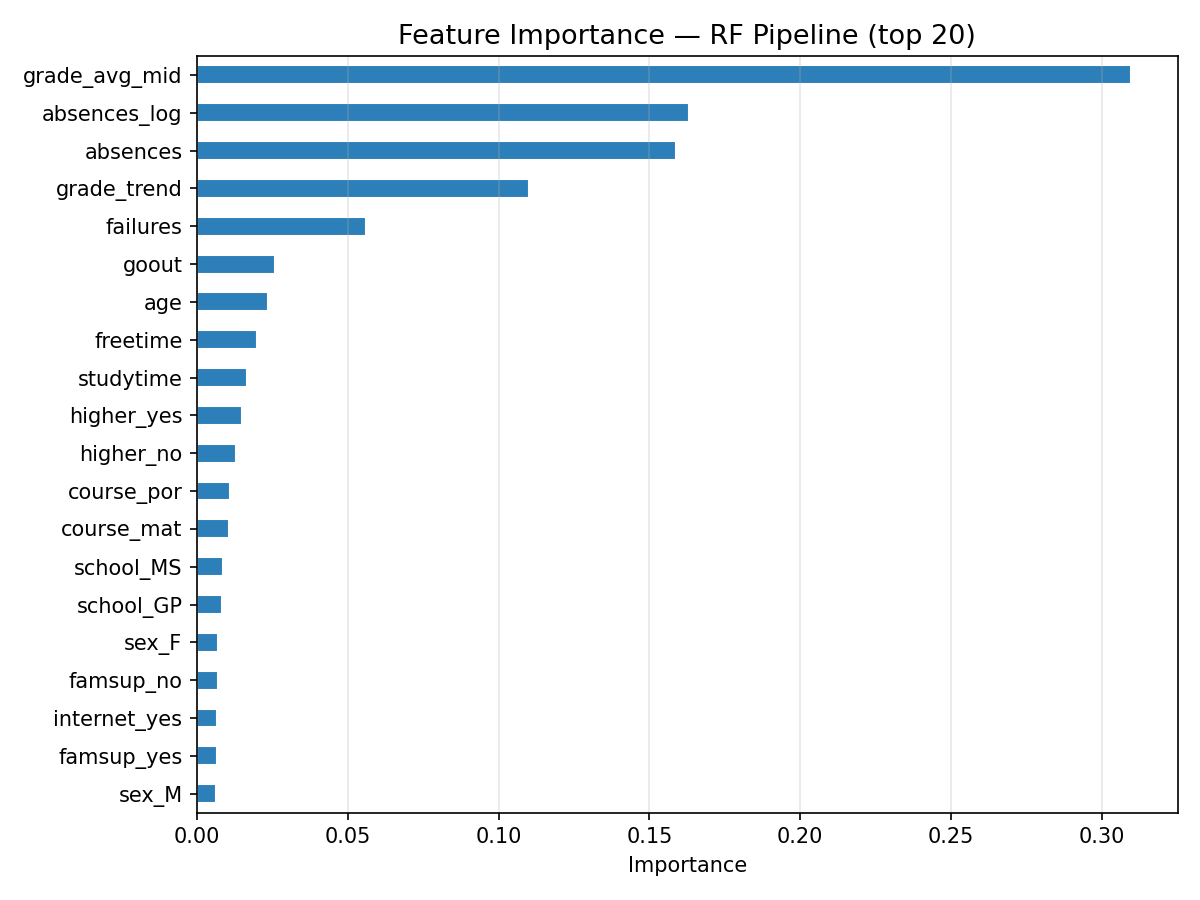

In [8]:
feature_importance_chart(X, y, paths)

from IPython.display import Image
display(Image(str(paths.figures / "feature_importance_risk.png")))


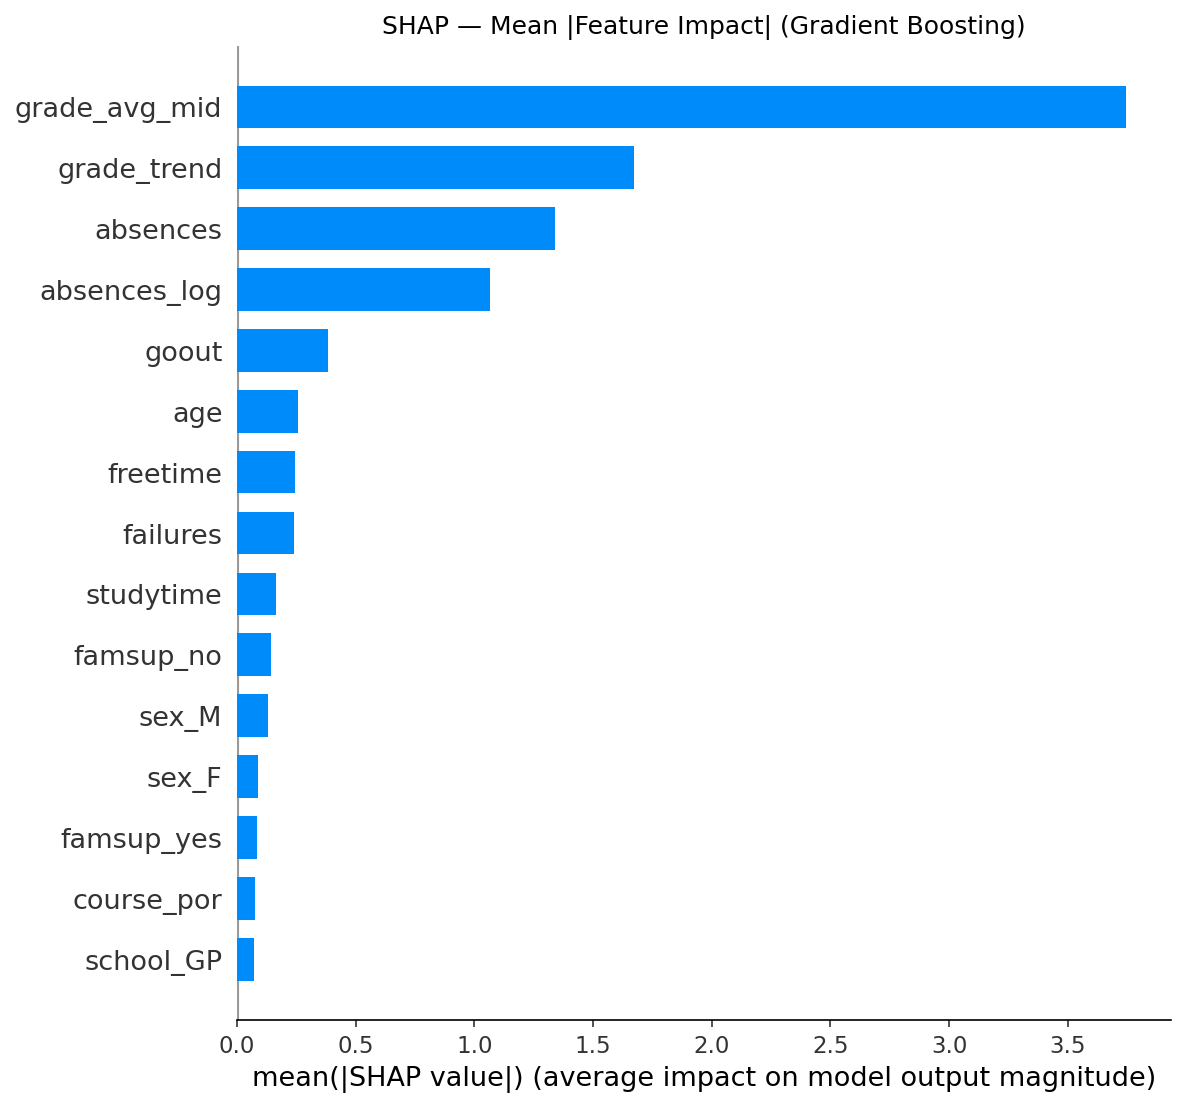

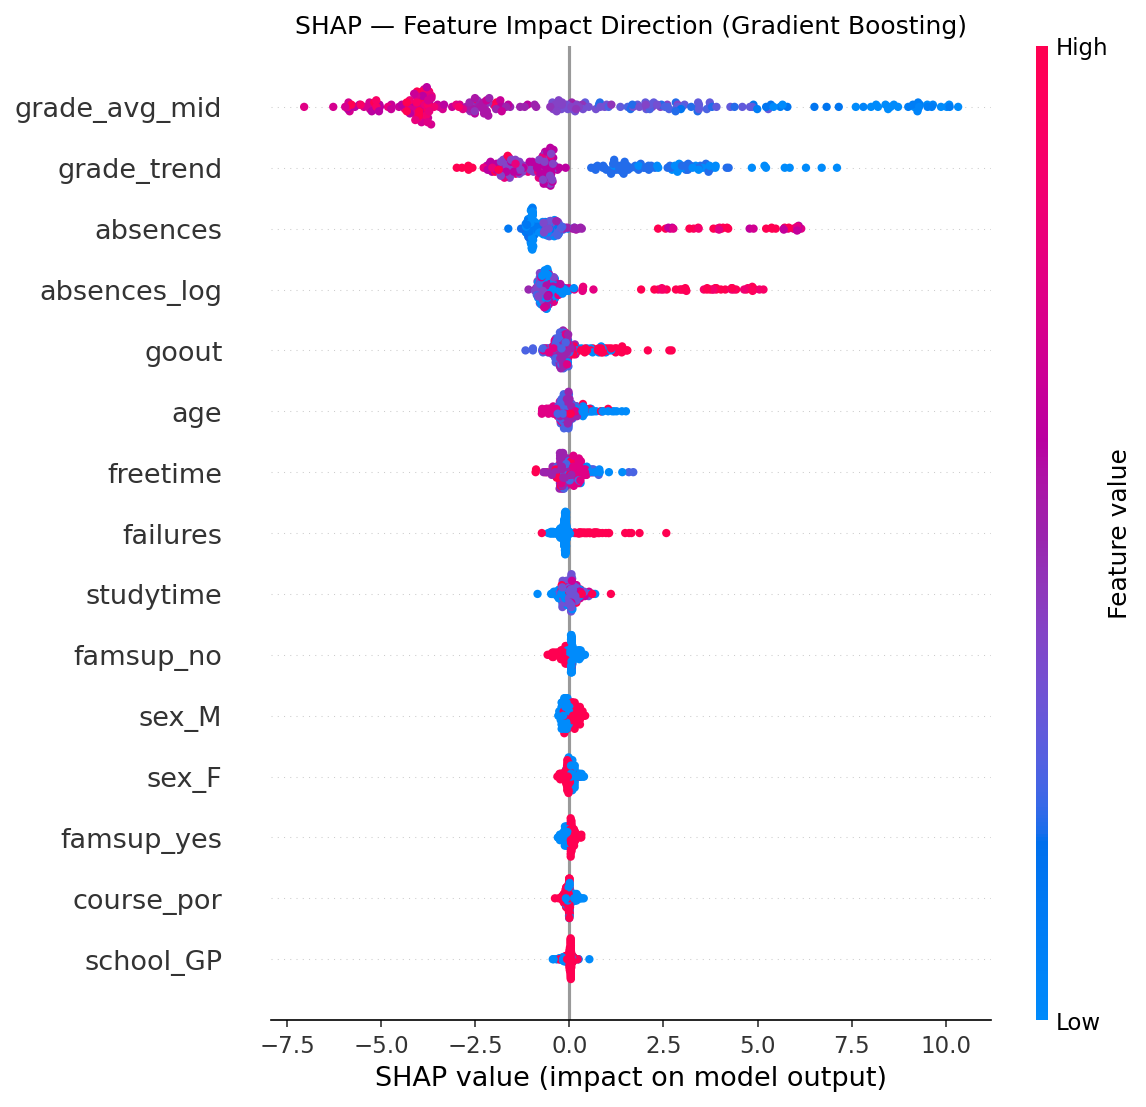

In [9]:
# SHAP TreeExplainer on Gradient Boosting
# Requires: pip install shap
shap_analysis(X, y, paths)

from IPython.display import Image
display(Image(str(paths.figures / "shap_summary_bar.png")))
display(Image(str(paths.figures / "shap_summary_dot.png")))


In [10]:
risk_preview = risk_score_preview(raw_df, paths)

print("Top 15 at-risk students (heuristic 0–100 score):")
display(risk_preview.head(15).style
        .background_gradient(subset=["risk_score"], cmap="RdYlGn_r")
        .map(lambda v: "color: darkred" if v == "high"
                  else ("color: darkorange" if v == "medium" else "color: darkgreen"),
                  subset=["risk_level"])
)


Top 15 at-risk students (heuristic 0–100 score):


,school,sex,age,absences,G1,G2,G3,risk_score,risk_level
216,GP,F,17,22,6,6,4,73.000000,high
550,GP,M,17,22,9,7,6,71.500000,high
103,GP,F,15,26,7,6,6,70.500000,high
118,GP,M,17,20,9,7,8,68.000000,high
234,GP,M,16,18,9,7,6,67.000000,high
280,GP,M,17,30,8,8,8,66.000000,high
651,GP,M,18,26,7,8,8,66.000000,high
203,GP,F,17,18,7,6,6,66.000000,high
307,GP,M,19,38,8,9,8,66.000000,high
183,GP,F,17,56,9,9,8,66.000000,high


In [11]:
print("All outputs:")
print(f"  Figures : {paths.figures}")
print(f"  Tables  : {paths.tables}")
import os
for f in sorted(paths.figures.glob("*.png")):
    print(f"    {f.name}")


All outputs:
  Figures : /home/beraer/projects/okul_asistani/data_science/reports/figures
  Tables  : /home/beraer/projects/okul_asistani/data_science/reports/tables
    confusion_matrix_gradient_boosting.png
    confusion_matrix_logistic_regression.png
    confusion_matrix_random_forest.png
    eda_absence_distribution.png
    eda_class_distribution.png
    eda_correlation_heatmap.png
    eda_grade_distributions.png
    eda_social_alcohol.png
    eda_social_demographic.png
    eda_social_family_health.png
    eda_social_parent_edu.png
    feature_importance_risk.png
    feature_set_comparison.png
    precision_recall_comparison.png
    roc_curve_comparison.png
    shap_summary_bar.png
    shap_summary_dot.png
